# Astrophysical Models

This notebook covers star formation efficiency models and UV Luminosity Functions.

## Star Formation Efficiency ($f_*$) Models

Using CAMB to estimate linear power spectrum.
cpl: w0,wa=-1,0
sigma_8=0.811
CAMB runtime: 1.82 s
Preparing cosmological solvers...
astropy will be used.
...done
MA is modelled with the EXP method
Using CAMB to estimate linear power spectrum.
cpl: w0,wa=-1,0
sigma_8=0.811
CAMB runtime: 1.77 s
Preparing cosmological solvers...
astropy will be used.
...done
MA is modelled with the HUBBLEscale method


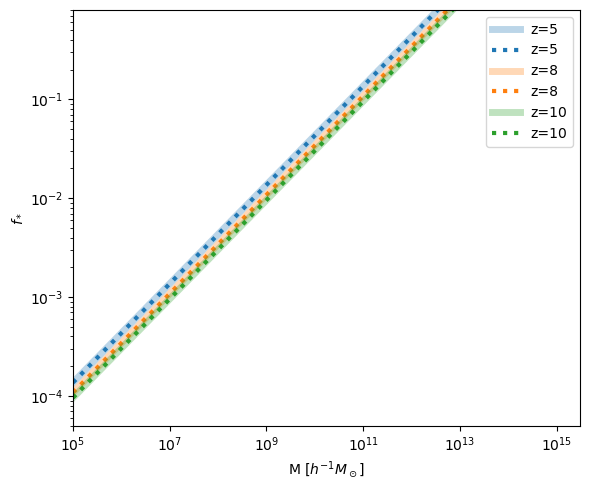

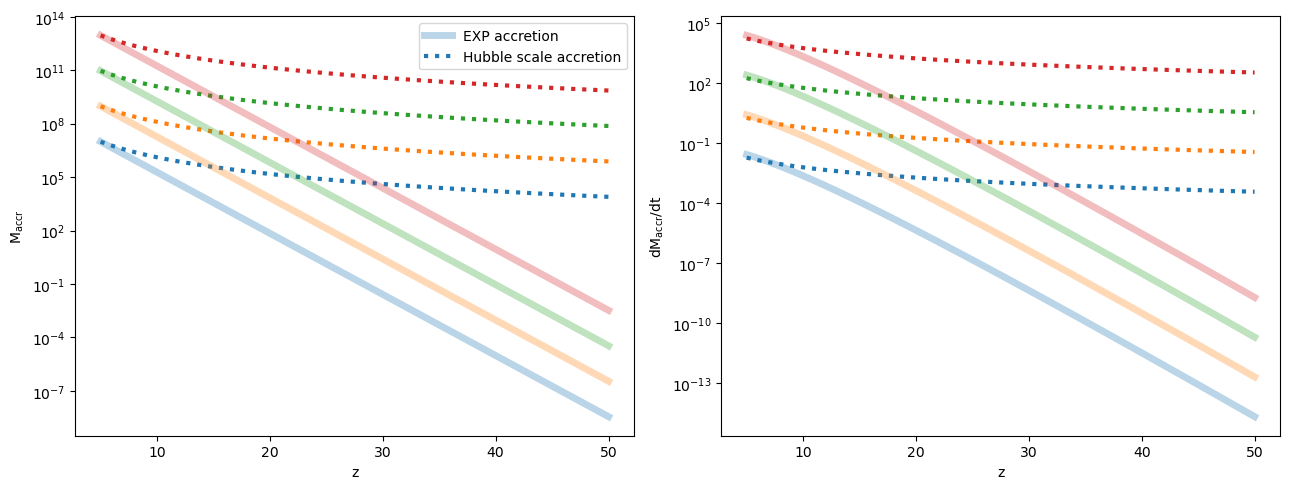

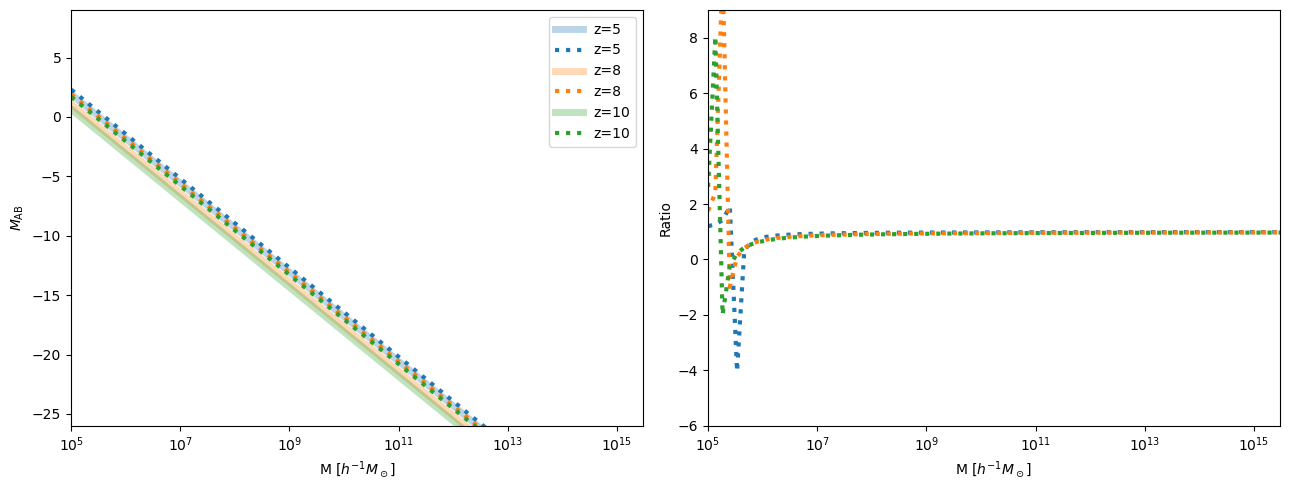

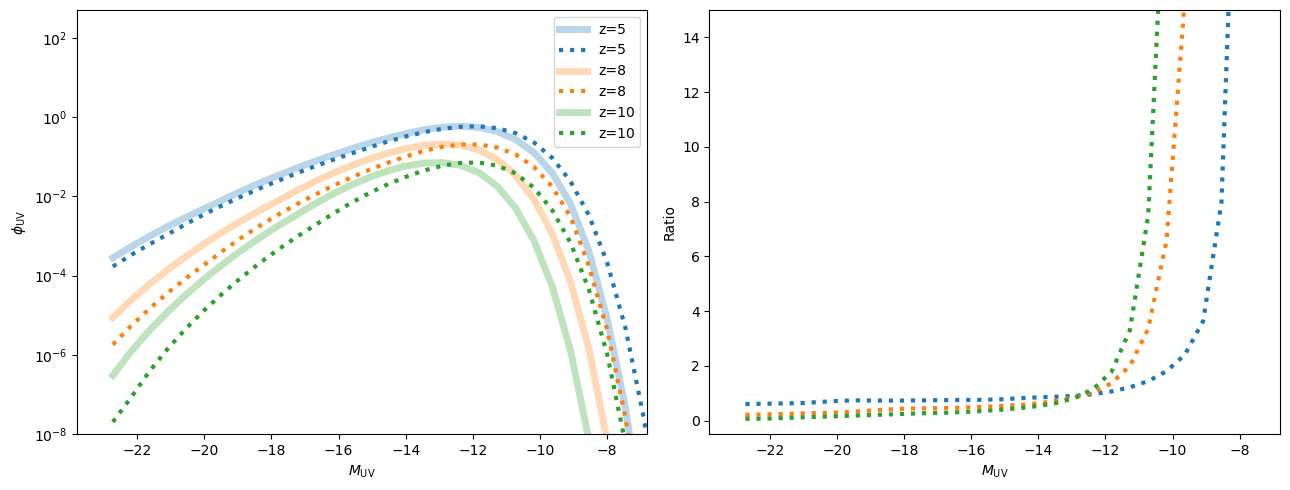

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import toolscosmo
import pickle, os, glob

from scipy.stats import binned_statistic
from scipy.interpolate import splev, splrep, interp1d
from scipy.interpolate import bisplev, bisplrep

chdir = './'

def set_param(**kwargs):
    ## set parameters
    par = toolscosmo.par(DE='cpl')

    # par.file.ps = chdir+"CDM_Planck15_pk.dat"
    par.file.ps  = "CAMB"
    Odm = kwargs.get('Odm', 0.266)
    Ob  = kwargs.get('Ob', 0.049)
    par.cosmo.Ob = Ob
    par.cosmo.Om = kwargs.get('Om', Odm+Ob) 
    par.cosmo.s8 = kwargs.get('s8', 0.830)
    par.cosmo.ns = kwargs.get('ns', 0.963)
    par.cosmo.h0 = kwargs.get('h0', 0.673) 
    par.DE.w0 = kwargs.get('w0', -1)
    par.DE.wa = kwargs.get('wa', 0)

    MA = kwargs.get('MA', 'EXP')
    if MA.upper()=='EXP':
        par.code.MA = 'EXP'
        par.MA.alpha_EXP = kwargs.get('MA_param', 0.79)
    elif MA.upper()=='EPS':
        par.code.MA = 'EPS'
        par.MA.Q_EPS = kwargs.get('MA_param', 0.6)
    else:
        par.code.MA = 'HUBBLEscale' #'21cmfast'
        par.MA.t_star = kwargs.get('MA_param', 0.5)

    par.code.NM = 80
    par.code.Nz = 100
    par.code.kmin = 1e-5
    par.code.kmax = 5e2
    par.code.Mmin = 1e5
    par.code.Mmax = 3e15 #3e15
    par.code.zmin = 5.0
    par.code.zmax = 50.0
    par.code.verbose = kwargs.get('verbose', True)

    par.lf.Muv_min = -23 #-24.25
    par.lf.Muv_max = -5 #-7.75
    par.lf.NMuv  = 33
    par.lf.sig_M = kwargs.get('sig_M', 0.56)  #scatter in UV magnitude for fixed halo mas
    par.lf.eps_sys = kwargs.get('eps_sys', 1)
    par.lf.f0_sfe  = kwargs.get('f0_sfe', 0.1) #0.14#
    par.lf.Mp_sfe  = kwargs.get('Mp_sfe', 10**11.28)
    par.lf.g1_sfe  = kwargs.get('g1_sfe', 0.49) #0.49
    par.lf.g2_sfe  = kwargs.get('g2_sfe', -0.60) #-0.60 
    par.lf.Mt_sfe  = kwargs.get('Mt_sfe', 10**4)
    par.lf.g3_sfe  = kwargs.get('g3_sfe', 5.0)
    par.lf.g4_sfe  = kwargs.get('g4_sfe', -5.0)
    par.lf.f0_sfe_nu = kwargs.get('f0_sfe_nu', -0.58) #0.0 #-0.8 #
    par.lf.Mp_sfe_nu = 0.0
    par.lf.Mt_sfe_nu = 0.0
    par.lf.g1_sfe_nu = 0.0
    par.lf.g2_sfe_nu = 0.0
    par.lf.g3_sfe_nu = 0.0
    par.lf.g4_sfe_nu = 0.0
    
    return par

def model_uvlfs(**kwargs):
    par = kwargs.get('param', set_param(**kwargs))    
    print_cosmo = kwargs.get('print_cosmo', False)
    if print_cosmo: 
        print(par.cosmo.__dict__)
        print(par.DE.__dict__)
    # print(kwargs)

    ## UV LFs
    f_duty = kwargs.get('f_duty', 1)
    uvlf = toolscosmo.UVLF(par)
    out_lf = uvlf.UV_luminosity(f_duty=f_duty)
    # print(out_lf.keys())
    return out_lf

lf_EXP = model_uvlfs(MA='EXP', g1_sfe=-0.5, g2_sfe=-0.5, g3_sfe=0, g4_sfe=0,
                    Mt_sfe=3.365e8*2, Mp_sfe=6.73e9, f_duty='EXP')
lf_21cmfast = model_uvlfs(MA='21cmfast', MA_param=0.3, g1_sfe=-0.5, g2_sfe=-0.5, g3_sfe=0, g4_sfe=0,
                    Mt_sfe=3.365e8*2, Mp_sfe=6.73e9, f_duty='EXP')

Mplot = [1e7,1e9,1e11,1e13]
zplot = [5,8,10] #[6,9,12,15]

fig, ax = plt.subplots(1,1,figsize=(6,5))
for jj,zj in enumerate(zplot):
    z_jdx = np.abs(lf_EXP['z']-zj).argmin()
    ax.loglog(lf_EXP['m'], lf_EXP['fstar'][z_jdx,:], 
            label=f'z={zj}', lw=5, c=f'C{jj}', alpha=0.3, ls='-')
    ax.loglog(lf_21cmfast['m'], lf_21cmfast['fstar'][z_jdx,:], 
            label=f'z={zj}', lw=3, c=f'C{jj}', alpha=1.0, ls=':')
ax.legend()
ax.axis([1e5,3e15,5e-5,8e-1])
ax.set_ylabel('$f_*$')
ax.set_xlabel('M [$h^{-1}M_\odot$]')
plt.tight_layout()
plt.show()

# exit()

# lf_EXP = model_uvlfs(MA='EXP')
# # lf_EPS = model_uvlfs(MA='EPS')
# lf_21cmfast = model_uvlfs(MA='21cmfast')

Mplot = [1e7,1e9,1e11,1e13]
fig, axs = plt.subplots(1,2,figsize=(13,5))
for jj,mj in enumerate(Mplot):
    m_jdx = np.abs(lf_EXP['m']-mj).argmin()
    ax = axs[0]
    ax.semilogy(lf_EXP['z'], lf_EXP['M_accr'][:,m_jdx], 
                lw=5, alpha=0.3, c=f'C{jj}', ls='-',
                label='EXP accretion' if jj==0 else None)
    # ax.semilogy(lf_EPS['z'], lf_EPS['M_accr'][:,m_jdx], 
    #             lw=4, alpha=0.7, c=f'C{jj}', ls='--',
    #             label='EPS accretion' if jj==0 else None)
    ax.semilogy(lf_21cmfast['z'], lf_21cmfast['M_accr'][:,m_jdx], 
                lw=3, alpha=1.0, c=f'C{jj}', ls=':',
                label='Hubble scale accretion' if jj==0 else None)
    ax = axs[1]
    ax.semilogy(lf_EXP['z'], lf_EXP['dMdt_accr'][:,m_jdx], 
                lw=5, alpha=0.3, c=f'C{jj}', ls='-',
                label='EXP accretion' if jj==0 else None)
    # ax.semilogy(lf_EPS['z'], lf_EPS['dMdt_accr'][:,m_jdx], 
    #             lw=4, alpha=0.7, c=f'C{jj}', ls='--',
    #             label='EPS accretion' if jj==0 else None)
    ax.semilogy(lf_21cmfast['z'], lf_21cmfast['dMdt_accr'][:,m_jdx], 
                lw=3, alpha=1.0, c=f'C{jj}', ls=':',
                label='Hubble scale accretion' if jj==0 else None)
axs[0].legend()
axs[0].set_ylabel('M$_\mathrm{accr}$')
axs[1].set_ylabel('dM$_\mathrm{accr}$/dt')
for ax in axs: ax.set_xlabel('z')
plt.tight_layout()
plt.show()


fig, axs = plt.subplots(1,2,figsize=(13,5))
for jj,zj in enumerate(zplot):
    z_jdx = np.abs(lf_EXP['z']-zj).argmin()
    ax = axs[0]
    ax.semilogx(lf_EXP['m'], lf_EXP['M_AB'][z_jdx,:], 
            label=f'z={zj}', lw=5, c=f'C{jj}', alpha=0.3, ls='-')
    ax.semilogx(lf_21cmfast['m'], lf_21cmfast['M_AB'][z_jdx,:], 
            label=f'z={zj}', lw=3, c=f'C{jj}', alpha=1.0, ls=':')
    ax = axs[1]
    ax.semilogx(lf_21cmfast['m'], lf_21cmfast['M_AB'][z_jdx,:]/lf_EXP['M_AB'][z_jdx,:], 
            label=f'z={zj}', lw=3, c=f'C{jj}', alpha=1.0, ls=':')
axs[0].legend()
axs[0].axis([1e5,3e15,-26,9])
axs[1].axis([1e5,3e15,-6,9])
axs[0].set_ylabel('$M_\mathrm{AB}$')
axs[1].set_ylabel('Ratio')
for ax in axs: ax.set_xlabel('M [$h^{-1}M_\odot$]')
plt.tight_layout()
plt.show()


fig, axs = plt.subplots(1,2,figsize=(13,5))
for jj,zj in enumerate(zplot):
    z_jdx = np.abs(lf_EXP['z']-zj).argmin()
    ax = axs[0]
    ax.plot(lf_EXP['uvlf']['Muv_mean'], lf_EXP['uvlf']['phi_uv'][z_jdx,:], 
            label=f'z={zj}', lw=5, c=f'C{jj}', alpha=0.3, ls='-')
    ax.plot(lf_21cmfast['uvlf']['Muv_mean'], lf_21cmfast['uvlf']['phi_uv'][z_jdx,:], 
            label=f'z={zj}', lw=3, c=f'C{jj}', alpha=1.0, ls=':')
    ax = axs[1]
    ax.plot(lf_21cmfast['uvlf']['Muv_mean'], lf_21cmfast['uvlf']['phi_uv'][z_jdx,:]/lf_EXP['uvlf']['phi_uv'][z_jdx,:], 
            label=f'z={zj}', lw=3, c=f'C{jj}', alpha=1.0, ls=':')
axs[0].legend()
axs[0].set_yscale('log')
axs[0].axis([-23.8,-6.8,1e-8,5e2]) #([-23.8,-15.8,1e-8,5e-2])
axs[1].axis([-23.8,-6.8,-0.5,15]) #([-23.8,-15.8,-0.5,15])
axs[0].set_ylabel('$\phi_\mathrm{UV}$')
axs[1].set_ylabel('Ratio')
for ax in axs: ax.set_xlabel('$M_\mathrm{UV}$')
plt.tight_layout()
plt.show()




## UV Luminosity Functions (UVLFs)

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import toolscosmo

lstyles = ['-', '--', '-.', ':']

#set parameters
par = toolscosmo.par()
par.file.ps = "CDM_Planck15_pk.dat"

par.code.zmin = 5
par.code.zmax = 40
par.code.Nz   = 50
par.code.dz_prime_lyal = 0.01
par.code.dz_prime_xray = 0.1

par.code.Mmin = 5e5  #5e4
par.code.Mmax = 2e15
par.code.NM   = 100

par.mf.window = 'tophat'
par.mf.c      = 2.5
par.mf.q      = 0.85
par.mf.p      = 0.3

par.code.MA = 'EXP' #'EPS'


par.lf.f0_sfe = 0.1 #0.05  #0.20
par.lf.g1_sfe = 0.49  #0.55  #-0.5
par.lf.g2_sfe = -0.61 #-1.03 #-0.5
par.lf.g3_sfe = 5  #0
par.lf.g4_sfe = -5 #0
par.lf.Mp_sfe = 2.0e11
par.lf.Mt_sfe = 7e8 #3.5e8 #7.0e7

par.lf.f0_sfe_nu = -0.1  #0.20
par.lf.g1_sfe_nu = 0
par.lf.g2_sfe_nu = 0
par.lf.g3_sfe_nu = 0
par.lf.g4_sfe_nu = 0
par.lf.Mp_sfe_nu = 0
par.lf.Mt_sfe_nu = 0

par.lf.Muv_min = -23.
par.lf.Muv_max = -8.0 #-15
par.lf.NMuv  = 20
par.lf.sig_M = 0.2
par.lf.eps_sys = 1.0

# print(par.xray.__dict__)
print(par.lf.__dict__)

## HMF
hmf = toolscosmo.mass_fct(par)

## UV LFs
M0 = 51.6
kappa  = 1.15e-28  # Msun yr^-1 /(erg s^-1 Hz^-1)
fstars = toolscosmo.fstar(hmf['z'], hmf['m'], 'lf', par)

m_ac = toolscosmo.mass_accr(par, output=hmf)
uvlf = toolscosmo.UVLF(par)
# out_lf = uvlf.Muv(); print(out_lf.keys())
out_lf = uvlf.UV_luminosity(); # print(out_lf.keys())

# fig, axs = plt.subplots(1,3,figsize=(14,4))
# z_plot = [6,7,8]
# ax = axs[0] # fig, ax = plt.subplots(1,1,figsize=(6,4))
# for ii,zi in enumerate(z_plot):
#     z_idx = np.abs(hmf['z']-zi).argmin() 
#     ax.loglog(hmf['m'], hmf['dndlnm'][z_idx,:], lw=3, ls=lstyles[ii], label='z={:.1f}'.format(zi))
# ax.legend()
# ax.axis([3e6,3e12,5e-6,8e2])
# ax.set_xlabel(r'$M$ [$h^{-1}$M$_\odot$]', fontsize=13)
# ax.set_ylabel(r'$\frac{\mathrm{d}n}{\mathrm{d}lnM}$', fontsize=15)
# # plt.tight_layout()
# # plt.show()

# z_plot = [6,7,8]
# ax = axs[1] # fig, ax = plt.subplots(1,1,figsize=(6,4))
# for ii,zi in enumerate(z_plot):
#     z_idx = np.abs(hmf['z']-zi).argmin() 
#     ax.loglog(hmf['m'], fstars[z_idx,:], lw=3, ls=lstyles[ii], label='z={:.1f}'.format(zi))
# ax.legend()
# ax.axis([5e5,3e14,5e-6,8e-2])
# ax.set_xlabel(r'$M$ [$h^{-1}$M$_\odot$]', fontsize=13)
# ax.set_ylabel(r'$f_\star$', fontsize=15)
# # plt.tight_layout()
# # plt.show()


# B2015_data = np.loadtxt('data/Bouwen2015_in_SZ21.txt')

# z_plot = [6,7,8]
# ax = axs[2] # fig, ax = plt.subplots(1,1,figsize=(6,4))
# B2015_z6_mean = B2015_data[:,1]/2.+B2015_data[:,2]/2.
# B2015_z6_std  = np.abs(B2015_data[:,2]-B2015_z6_mean)
# ax.errorbar(B2015_data[:,0], B2015_z6_mean, yerr=B2015_z6_std, c='r', ls=' ')
# for ii,zi in enumerate(z_plot):
#     z_idx = np.abs(out_lf['z']-zi).argmin() 
#     ax.plot(out_lf['uvlf']['Muv_mean'], out_lf['uvlf']['phi_uv'][z_idx,:], lw=3, ls=lstyles[ii], label='z={:.1f}'.format(zi))
# ax.set_yscale('log')
# ax.legend()
# ax.axis([-23.2,-14.8,5e-7,4e-2])
# ax.set_xlabel(r'$M_{\rm UV}$', fontsize=13)
# ax.set_ylabel(r'$\phi (M_{\rm UV})$', fontsize=15)
# plt.tight_layout()
# plt.show()


# z_plot = [6,7,8]
# fig0, ax01 = plt.subplots(1,2,figsize=(9,4))
# ax0, ax1 = ax01
# for ii,zi in enumerate(z_plot):
#     z_idx = np.abs(out_lf['z']-zi).argmin() 
#     ax0.plot(out_lf['M_AB'][z_idx,:], out_lf['m'], lw=3, ls=lstyles[ii], label='z={:.1f}'.format(zi))
#     ax1.loglog(out_lf['m'], out_lf['fstar'][z_idx,:], lw=3, ls=lstyles[ii], label='z={:.1f}'.format(zi))
# ax0.set_yscale('log')
# ax0.legend()
# # ax0.axis([-26,-7,2e5,3e15])
# ax0.set_xlabel(r'$M_{\rm UV}$', fontsize=13)
# ax0.set_ylabel(r'$M_{\rm h}$', fontsize=15)
# ax1.legend()
# ax1.axis([5e5,3e14,5e-6,8e-2])
# ax1.set_xlabel(r'$M$ [$h^{-1}$M$_\odot$]', fontsize=13)
# ax1.set_ylabel(r'$f_\star$', fontsize=15)
# plt.tight_layout()
# # plt.show()

Park19_Bouwens_data   = np.loadtxt('data/Park19_Bouwens.txt')
Park19_Atek_data      = np.loadtxt('data/Park19_Atek.txt')
Park19_Livermore_data = np.loadtxt('data/Park19_Livermore.txt')
Park19_Ishigaki_data  = np.loadtxt('data/Park19_Ishigaki.txt')
Park19_Oesch_data     = np.loadtxt('data/Park19_Oesch.txt')

fig, axs = plt.subplots(1,4,figsize=(15,4))
# j,zj = 0, 6
for j,zj in enumerate([6,7,8,10]):
    axs[j].set_title('$z\sim {}$'.format(zj))
    az = np.where(Park19_Bouwens_data[:,-1]==zj)
    xx, yy = Park19_Bouwens_data[az,0].squeeze(), Park19_Bouwens_data[az,1].squeeze()
    yl, yp = Park19_Bouwens_data[az,2].squeeze(), Park19_Bouwens_data[az,3].squeeze()
    axs[j].errorbar(xx, yy, yerr=[yy-yl,yp-yy], #np.max([yy-yl,yp-yy], axis=0), 
                    ls=' ', marker='o', markeredgecolor='k', color='coral', 
                    label='Bouwens+2015,2017' if j==0 else None)
    az = np.where(Park19_Atek_data[:,-1]==zj)
    xx, yy = Park19_Atek_data[az,0].squeeze(), Park19_Atek_data[az,1].squeeze()
    yl, yp = Park19_Atek_data[az,2].squeeze(), Park19_Atek_data[az,3].squeeze()
    axs[j].errorbar(xx, yy, yerr=[yy-yl,yp-yy], #np.max([yy-yl,yp-yy], axis=0), 
                    ls=' ', marker='D', markeredgecolor='k', color='orange', 
                    label='Atek+2018' if j==0 else None)
    az = np.where(Park19_Livermore_data[:,-1]==zj)
    xx, yy = Park19_Livermore_data[az,0].squeeze(), Park19_Livermore_data[az,1].squeeze()
    yl, yp = Park19_Livermore_data[az,2].squeeze(), Park19_Livermore_data[az,3].squeeze()
    axs[j].errorbar(xx, yy, yerr=[yy-yl,yp-yy], #np.max([yy-yl,yp-yy], axis=0), 
                    ls=' ', marker='s', markeredgecolor='k', color='lightblue', 
                    label='Livermore+2017' if j==2 else None)
    az = np.where(Park19_Ishigaki_data[:,-1]==zj)
    xx, yy = Park19_Ishigaki_data[az,0].squeeze(), Park19_Ishigaki_data[az,1].squeeze()
    yl, yp = Park19_Ishigaki_data[az,2].squeeze(), Park19_Ishigaki_data[az,3].squeeze()
    axs[j].errorbar(xx, yy, yerr=[yy-yl,yp-yy], #np.max([yy-yl,yp-yy], axis=0), 
                    ls=' ', marker='p', markeredgecolor='k', color='violet', 
                    label='Ishigaki+2017' if j==2 else None)
    az = np.where(Park19_Oesch_data[:,-1]==zj)
    xx, yy = Park19_Oesch_data[az,0].squeeze(), Park19_Oesch_data[az,1].squeeze()
    yl, yp = Park19_Oesch_data[az,2].squeeze(), Park19_Oesch_data[az,3].squeeze()
    axs[j].errorbar(xx, yy, yerr=[yy-yl,yp-yy], #np.max([yy-yl,yp-yy], axis=0), 
                    ls=' ', marker='h', markeredgecolor='k', color='green', 
                    label='Oesch+2017' if j==3 else None)
    axs[j].set_yscale('log')
    axs[j].axis([-23,-9,7e-6,3e2])
    z_jdx = np.abs(out_lf['z']-zj).argmin() 
    axs[j].plot(out_lf['uvlf']['Muv_mean'], out_lf['uvlf']['phi_uv'][z_jdx,:], 
                    lw=3, ls='-', color='k', label='Model' if j==1 else None)
    axs[j].legend()
    axs[j].set_xlabel(r'$M_{\rm UV}$', fontsize=13)
    axs[j].set_ylabel(r'$\phi (M_{\rm UV})$', fontsize=15)
plt.tight_layout()
plt.show()

{'Muv_min': -23.0, 'Muv_max': -8.0, 'NMuv': 20, 'sig_M': 0.2, 'eps_sys': 1.0, 'f0_sfe': 0.1, 'Mp_sfe': 200000000000.0, 'g1_sfe': 0.49, 'g2_sfe': -0.61, 'Mt_sfe': 700000000.0, 'g3_sfe': 5, 'g4_sfe': -5, 'f0_sfe_nu': -0.1, 'Mp_sfe_nu': 0, 'Mt_sfe_nu': 0, 'g1_sfe_nu': 0, 'g2_sfe_nu': 0, 'g3_sfe_nu': 0, 'g4_sfe_nu': 0}
Provide linear power spectrum via param.file.ps
Option: file, CLASS, CAMB, BACCO


TypeError: 'NoneType' object is not subscriptable